In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

In [2]:
ESMS = ['mpi-esm1-2-hr','ukesm1-0-ll','ipsl-cm6a-lr']



In [3]:
def generate_plot(mapdata,title,ax,plot_diff):
    """ 
    Good practice for a new function: define all the inputs:
    mapdata: the data we want to map. Should be dimensions (lon, lat)
    title: string, title of the plot
    ax: the axes we are plotting within
    plot_diff: If True, this is a difference map and the color bar should 
        center on 0.
    """

    if plot_diff==True:
        clevs = np.arange(-0.3,0.35,0.05)
    else:
        clevs = np.arange(240,312,8)

    cs=ax.contourf(mapdata.longitude, mapdata.latitude, mapdata, clevs,
                   transform = ccrs.PlateCarree(central_longitude=0),
                   cmap='coolwarm')              
    ax.set_title(title)
    ax.coastlines()

    return cs

In [4]:
def calculate_global_mean(inputdata):
    
    weights = np.empty_like(inputdata)
    nlat=len(inputdata.latitude)
    #print(np.min(inputdata),np.max(inputdata))
    
    for kk in range(nlat):
        weights[kk,:] = np.where(inputdata[kk,:]>200,
                                 np.cos(np.deg2rad(inputdata.latitude[kk])),
                                 np.nan)
    #print(np.min(weights),np.max(weights))

    #print('unweighted global mean = ',np.mean(inputdata*weights))
    global_mean=np.nansum(inputdata * weights, axis=(0,1)) / np.nansum(weights, axis=(0,1))
    #print('weighted global mean = ',global_mean)
    del(weights)
    
    return global_mean

In [24]:
def plot_zonal_mean(inputdata,latitude):
    
    nlat = len(latitude)
    nlon = len(inputdata.longitude)
    weights = np.empty_like(inputdata)
    zonal_mean = np.empty(nlat)
    zonal_SD = np.empty(nlat)
    for kk in range(nlat):
        if np.any(abs(inputdata[kk,:]))>0.000001:
            weights[kk,:] = np.where(abs(inputdata[kk,:])>0.000001,
                                     np.cos(np.deg2rad(latitude[kk])),
                                     np.nan)
            zonal_mean[kk] = np.nansum(inputdata[kk,:]*weights[kk,:]) / np.nansum(weights[kk,:])
            num = np.nansum(((inputdata[kk,:]*weights[kk,:]) - zonal_mean[kk])**2)
            zonal_SD[kk] = np.sqrt(num/np.nansum(weights[kk,:]))
            print(kk,latitude.data[kk])
            print('mean:',zonal_mean[kk],zonal_SD[kk])
    
    fig = plt.figure(1)
    plt.plot(zonal_mean,latitude)
    plt.fill_betweenx(latitude, zonal_mean-zonal_SD, zonal_mean+zonal_SD)

    

    plt.title('Zonal Mean ')
    plt.xlabel('$\Delta$ Temperature (K)');
    plt.ylabel('Latitude');
    fig.show()

<>:26: SyntaxWarning: invalid escape sequence '\D'
<>:26: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_4014307/1576689005.py:26: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('$\Delta$ Temperature (K)');


mpi-esm1-2-hr  Global mean with no LUC: 286.62512 Global mean with afforestation: 286.65164


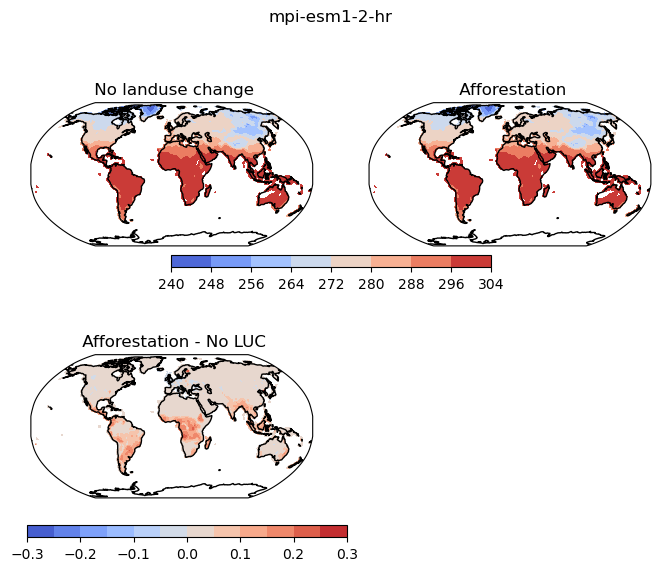

/tmp/ipykernel_4014307/2034747123.py:13: RuntimeWarning: invalid value encountered in scalar divide
  zonal_mean[kk] = np.nansum(inputdata[kk,:]*weights[kk,:]) / np.nansum(weights[kk,:])
/tmp/ipykernel_4014307/2034747123.py:15: RuntimeWarning: invalid value encountered in scalar divide
  zonal_SD[kk] = np.sqrt(num/np.nansum(weights[kk,:]))
/tmp/ipykernel_4014307/2034747123.py:13: RuntimeWarning: invalid value encountered in scalar divide
  zonal_mean[kk] = np.nansum(inputdata[kk,:]*weights[kk,:]) / np.nansum(weights[kk,:])
/tmp/ipykernel_4014307/2034747123.py:15: RuntimeWarning: invalid value encountered in scalar divide
  zonal_SD[kk] = np.sqrt(num/np.nansum(weights[kk,:]))
/tmp/ipykernel_4014307/2034747123.py:13: RuntimeWarning: invalid value encountered in scalar divide
  zonal_mean[kk] = np.nansum(inputdata[kk,:]*weights[kk,:]) / np.nansum(weights[kk,:])
/tmp/ipykernel_4014307/2034747123.py:15: RuntimeWarning: invalid value encountered in scalar divide
  zonal_SD[kk] = np.sqrt(num/

0 -89.0
mean: nan nan
1 -87.0
mean: nan nan
2 -85.0
mean: nan nan
3 -83.0
mean: nan nan
4 -81.0
mean: nan nan
5 -79.0
mean: nan nan
6 -77.0
mean: nan nan
7 -75.0
mean: nan nan
8 -73.0
mean: nan nan
9 -71.0
mean: nan nan
10 -69.0
mean: nan nan
11 -67.0
mean: nan nan
12 -65.0
mean: nan nan
13 -63.0
mean: nan nan
14 -61.0
mean: nan nan
15 -59.0
mean: 272.9197692871094 0.0
16 -57.0
mean: 273.6069641113281 0.0
17 -55.0
mean: 280.33380126953125 1698.4830322265625
18 -53.0
mean: 282.2248840332031 1532.5869140625
19 -51.0
mean: 284.5042419433594 1805.5716552734375
20 -49.0
mean: 284.82757568359375 1845.627685546875
21 -47.0
mean: 286.2805480957031 2127.778076171875
22 -45.0
mean: 287.6797180175781 2419.089599609375
23 -43.0
mean: 289.591064453125 2971.873046875
24 -41.0
mean: 290.46502685546875 3280.403564453125
25 -39.0
mean: 292.28326416015625 4122.638671875
26 -37.0
mean: 292.9067077636719 5496.96484375
27 -35.0
mean: 295.08660888671875 7478.07470703125
28 -33.0
mean: 296.701904296875 9781.

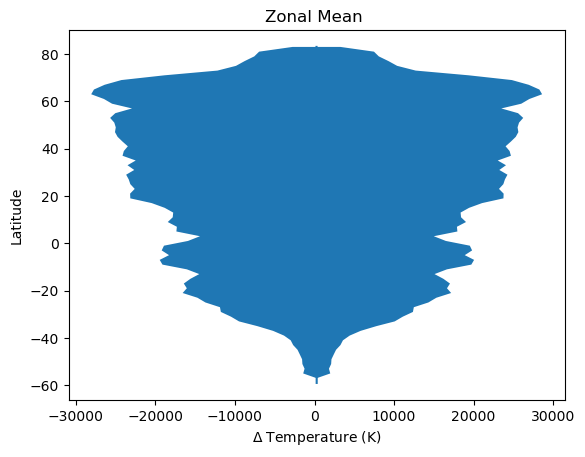

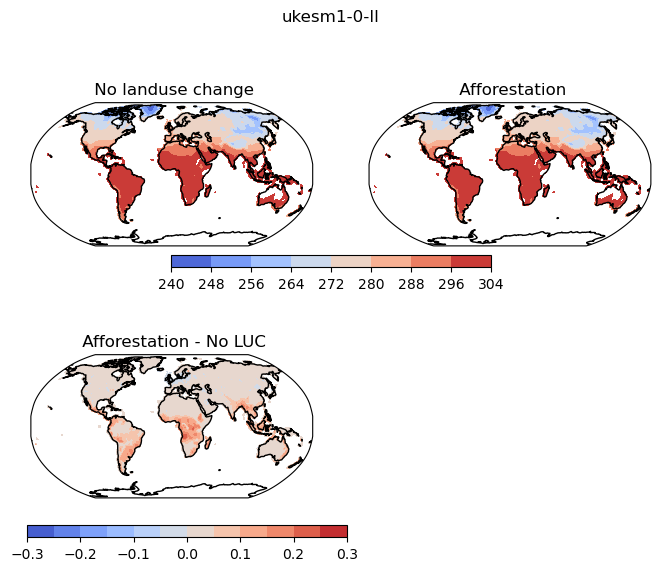

/tmp/ipykernel_4014307/2034747123.py:13: RuntimeWarning: invalid value encountered in scalar divide
  zonal_mean[kk] = np.nansum(inputdata[kk,:]*weights[kk,:]) / np.nansum(weights[kk,:])
/tmp/ipykernel_4014307/2034747123.py:15: RuntimeWarning: invalid value encountered in scalar divide
  zonal_SD[kk] = np.sqrt(num/np.nansum(weights[kk,:]))
/tmp/ipykernel_4014307/2034747123.py:13: RuntimeWarning: invalid value encountered in scalar divide
  zonal_mean[kk] = np.nansum(inputdata[kk,:]*weights[kk,:]) / np.nansum(weights[kk,:])
/tmp/ipykernel_4014307/2034747123.py:15: RuntimeWarning: invalid value encountered in scalar divide
  zonal_SD[kk] = np.sqrt(num/np.nansum(weights[kk,:]))
/tmp/ipykernel_4014307/2034747123.py:13: RuntimeWarning: invalid value encountered in scalar divide
  zonal_mean[kk] = np.nansum(inputdata[kk,:]*weights[kk,:]) / np.nansum(weights[kk,:])
/tmp/ipykernel_4014307/2034747123.py:15: RuntimeWarning: invalid value encountered in scalar divide
  zonal_SD[kk] = np.sqrt(num/

0 -89.0
mean: nan nan
1 -87.0
mean: nan nan
2 -85.0
mean: nan nan
3 -83.0
mean: nan nan
4 -81.0
mean: nan nan
5 -79.0
mean: nan nan
6 -77.0
mean: nan nan
7 -75.0
mean: nan nan
8 -73.0
mean: nan nan
9 -71.0
mean: nan nan
10 -69.0
mean: nan nan
11 -67.0
mean: nan nan
12 -65.0
mean: nan nan
13 -63.0
mean: nan nan
14 -61.0
mean: nan nan
15 -59.0
mean: 273.10577392578125 0.0
16 -57.0
mean: 274.523193359375 0.0
17 -55.0
mean: 280.4136047363281 1698.9666748046875
18 -53.0
mean: 282.3891296386719 1533.4788818359375
19 -51.0
mean: 284.5628356933594 1805.943603515625
20 -49.0
mean: 285.2364807128906 1848.2769775390625
21 -47.0
mean: 287.0672607421875 2133.62548828125
22 -45.0
mean: 288.3492126464844 2424.719482421875
23 -43.0
mean: 289.81805419921875 2974.203125
24 -41.0
mean: 290.6769714355469 3282.79736328125
25 -39.0
mean: 291.9334411621094 4117.70458984375
26 -37.0
mean: 292.7005310058594 5493.095703125
27 -35.0
mean: 294.8162536621094 7471.2236328125
28 -33.0
mean: 296.6279296875 9779.35644

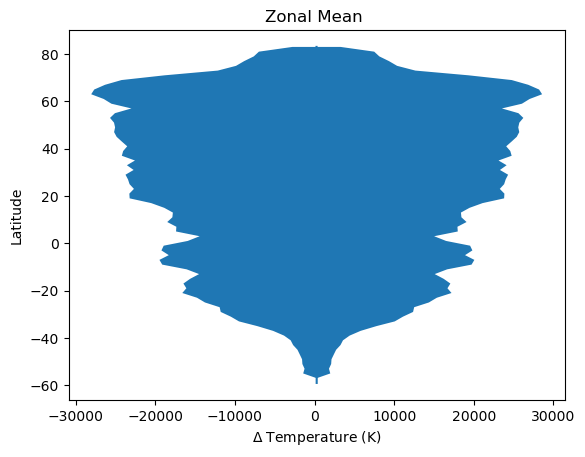

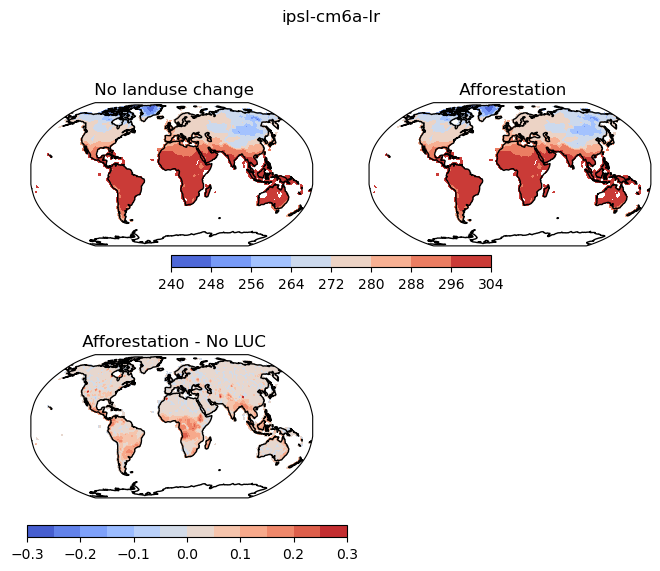

0 -89.0
mean: nan nan
1 -87.0
mean: nan nan
2 -85.0
mean: nan nan
3 -83.0
mean: nan nan
4 -81.0
mean: nan nan
5 -79.0
mean: nan nan
6 -77.0
mean: nan nan
7 -75.0
mean: nan nan
8 -73.0
mean: nan nan
9 -71.0
mean: nan nan
10 -69.0
mean: nan nan
11 -67.0
mean: nan nan
12 -65.0
mean: nan nan
13 -63.0
mean: nan nan
14 -61.0
mean: nan nan
15 -59.0
mean: 273.1449279785156 0.0
16 -57.0
mean: 274.5158996582031 0.0
17 -55.0
mean: 279.6076354980469 1694.0833740234375
18 -53.0
mean: 281.25823974609375 1527.3375244140625
19 -51.0
mean: 283.189208984375 1797.2257080078125
20 -49.0
mean: 283.6951599121094 1838.2891845703125
21 -47.0
mean: 285.2257385253906 2119.93798828125
22 -45.0
mean: 286.5710754394531 2409.766845703125
23 -43.0
mean: 288.7323303222656 2963.060546875
24 -41.0
mean: 290.0360412597656 3275.558837890625
25 -39.0
mean: 291.964599609375 4118.14453125
26 -37.0
mean: 292.65057373046875 5492.158203125
27 -35.0
mean: 294.7812805175781 7470.33740234375
28 -33.0
mean: 296.7208251953125 9782.

/tmp/ipykernel_4014307/2034747123.py:13: RuntimeWarning: invalid value encountered in scalar divide
  zonal_mean[kk] = np.nansum(inputdata[kk,:]*weights[kk,:]) / np.nansum(weights[kk,:])
/tmp/ipykernel_4014307/2034747123.py:15: RuntimeWarning: invalid value encountered in scalar divide
  zonal_SD[kk] = np.sqrt(num/np.nansum(weights[kk,:]))
/tmp/ipykernel_4014307/2034747123.py:13: RuntimeWarning: invalid value encountered in scalar divide
  zonal_mean[kk] = np.nansum(inputdata[kk,:]*weights[kk,:]) / np.nansum(weights[kk,:])
/tmp/ipykernel_4014307/2034747123.py:15: RuntimeWarning: invalid value encountered in scalar divide
  zonal_SD[kk] = np.sqrt(num/np.nansum(weights[kk,:]))
/tmp/ipykernel_4014307/2034747123.py:13: RuntimeWarning: invalid value encountered in scalar divide
  zonal_mean[kk] = np.nansum(inputdata[kk,:]*weights[kk,:]) / np.nansum(weights[kk,:])
/tmp/ipykernel_4014307/2034747123.py:15: RuntimeWarning: invalid value encountered in scalar divide
  zonal_SD[kk] = np.sqrt(num/

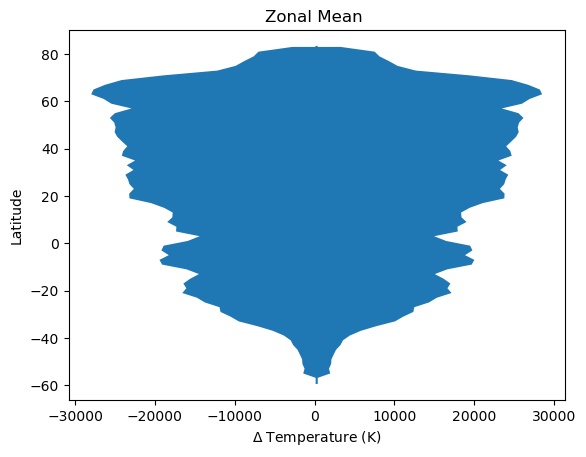

In [23]:
# This loops through the ESMs that were used for driving the land surface model
for esm in ESMS:
    dset1 = xr.open_dataset('/bdd/ESM2025/WP10/jules/jules_'+esm+'_ssp126_nolucaff_tsl.monthly.nc')
    dset2 = xr.open_dataset('/bdd/ESM2025/WP10/jules/jules_'+esm+'_ssp126_agtoaff_tsl.monthly.nc')
    
    noluc_mean = np.mean(dset1['tsl'][0,0:120],axis=0)
    aff_mean = np.mean(dset2['tsl'][0,0:120],axis=0)

    noluc_global_mean = calculate_global_mean(noluc_mean)
    aff_global_mean = calculate_global_mean(aff_mean)

    print(esm,' Global mean with no LUC:',noluc_global_mean, \
          'Global mean with afforestation:',aff_global_mean)
    
    # Create a 2x2 plot
    fig,axes=plt.subplots(2,2, figsize=[8,6],
                          subplot_kw=dict(projection=ccrs.Robinson(central_longitude=0)))

    # Top Left
    ax=axes[0,0]
    cs=generate_plot(noluc_mean,' No landuse change',ax,False)

    # Top Right
    ax=axes[0,1]
    cs2=generate_plot(aff_mean,' Afforestation',ax,False)
   
    # Add a colorbar axis for the first two maps
    # add_axes: Creates a new axes where you will draw the colorbar.
    #           x location of bottom left corner of the box
    #           y location of the bottom left corner
    #           width of the box
    #           height of the box
    cbar_ax = fig.add_axes([0.3, 0.55, 0.4, 0.02])
    cbar=fig.colorbar(cs2, cax=cbar_ax, orientation='horizontal')

    # Bottom Left
    ax=axes[1,0]
    cs3=generate_plot(aff_mean-noluc_mean,' Afforestation - No LUC',ax,True)

    cbar_ax = fig.add_axes([0.12, 0.1, 0.4, 0.02])
    cbar=fig.colorbar(cs3, cax=cbar_ax,orientation='horizontal')

    # Delete the bottom right axes since we're not using it.
    fig.delaxes(axes[1,1])
    
    # Add a title at the top
    plt.suptitle(esm)
    # Save a png
    plt.savefig('afforestation_'+esm+'.png',format="png", dpi=400)    

    plt.show()

    plot_zonal_mean(aff_mean,aff_mean.latitude)
    
    del(dset1,dset2)